<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
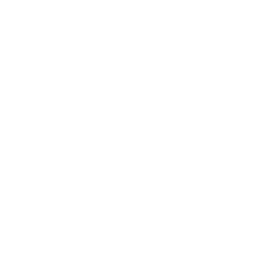
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Kundenrisikoprofilierung mittels kanonischer Diskriminanzanalyse</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Finanzdienstleistungen / Kreditrisikoanalyse &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Drei Kreditstatusgruppen in einem Verbraucher-Hypothekenportfolio — **ausgefallen**, **laufend** und **vorzeitig zurückgezahlt** — unterscheiden sich gleichzeitig entlang mehrerer Dimensionen der finanziellen Gesundheit, was jede einzelne Kennzahl zu einem schwachen Risikosignal macht. Dieses Notebook wendet **PROC CANDISC** (kanonische Diskriminanzanalyse) auf eine Risikoprüfungsstichprobe von 100 Kunden an und verdichtet sechs korrelierte Finanzkennzahlen zu zwei kanonischen Dimensionen, die die Trennung zwischen den drei Statusgruppen maximieren.

Die erste kanonische Dimension trägt nahezu die gesamte Trennung zwischen den Gruppen — kanonische Korrelation **0.958**, teilt **91.8%** ihrer Varianz mit der Gruppenzugehörigkeit — und ordnet die Kreditnehmer sauber von ausgefallen an einem Extrem bis zu vorzeitig zurückgezahlt am anderen. Die zweite Dimension (kanonische Korrelation **0.503**, quadriert **0.254**) fügt einen sekundären Kontrast hinzu, der von der Verzugshistorie und dem Verschuldungsgrad angeführt wird. Quadrierte Mahalanobis-Distanzen bestätigen, dass die Zentroide **DEFAULT** und **PREPAID** das am weitesten getrennte Paar bilden (**75.3**), wobei **CURRENT** zwischen ihnen liegt (34.3 von DEFAULT, 10.1 von PREPAID). Die resultierenden kanonischen Scores bilden einen kompakten zusammengesetzten Risikoindex, der für die Portfoliosegmentierung und die Scorecard-Kalibrierung geeignet ist.

## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|--------|
| WORK.LOAN_PROFILES | Synthetische finanzielle Kennzahlen und Verhaltensmetriken von Kunden, gekennzeichnet nach Kreditstatus, gezogen als ausgewogene Risikoprüfungsstichprobe | 100 |

Die Stichprobe überrepräsentiert bewusst ausgefallene und vorzeitig zurückgezahlte Konten (eine Ziehung im Fall-Kontroll-Stil), sodass jede Statusgruppe groß genug ist, um eine stabile gruppeninterne Kovarianzstruktur für die Diskriminanzanalyse zu schätzen.

---

In [1]:
/* --------------------------------------------------------
   Generate a synthetic loan-customer risk-review sample.
   Three status groups (DEFAULT / CURRENT / PREPAID) are
   over-sampled toward the risk tails so each class is large
   enough for a stable within-group covariance estimate.
   -------------------------------------------------------- */
DATEN work.loan_profiles;
    AUFRUFEN streaminit(42);
    LÄNGE loan_status $10 vintage $7 customer_id $12;
    FELD statuses[3] $10 _temporary_ ('DEFAULT' 'CURRENT' 'PREPAID');
    FELD vintages[4] $7 _temporary_ ('2022-Q1' '2022-Q3' '2023-Q1' '2023-Q3');
    AUSFÜHRUNG i = 1 BIS 20000;
        customer_id = cat('CUST-', PUT(i, z6.));
        vintage = vintages[int(rand('uniform') * 4) + 1];
        status_prob = rand('uniform');
        WENN status_prob < 0.30 DANN status_idx = 1;       /* DEFAULT */
        SONST WENN status_prob < 0.70 DANN status_idx = 2;  /* CURRENT */
        SONST status_idx = 3;                             /* PREPAID */
        loan_status = statuses[status_idx];
        /* Financial ratios separate the three status groups */
        WENN loan_status = 'DEFAULT' DANN AUSFÜHRUNG;
            dti_ratio          = rand('normal', 0.58, 0.12);
            ltv_ratio          = rand('normal', 0.92, 0.10);
            payment_to_income  = rand('normal', 0.42, 0.08);
            credit_utilization = rand('normal', 0.85, 0.10);
            months_delinquent  = int(rand('exponential') * 4) + 1;
            savings_balance    = rand('exponential') * 4000 + 200;
        ENDE;
        SONST WENN loan_status = 'CURRENT' DANN AUSFÜHRUNG;
            dti_ratio          = rand('normal', 0.35, 0.10);
            ltv_ratio          = rand('normal', 0.78, 0.09);
            payment_to_income  = rand('normal', 0.28, 0.07);
            credit_utilization = rand('normal', 0.45, 0.15);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 8000 + 200;
        ENDE;
        SONST AUSFÜHRUNG;
            dti_ratio          = rand('normal', 0.22, 0.07);
            ltv_ratio          = rand('normal', 0.60, 0.12);
            payment_to_income  = rand('normal', 0.20, 0.05);
            credit_utilization = rand('normal', 0.25, 0.12);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 16000 + 500;
        ENDE;
        /* Round and constrain ratios to valid ranges */
        dti_ratio          = round(dti_ratio, 0.001);
        ltv_ratio          = round(ltv_ratio, 0.001);
        payment_to_income  = round(payment_to_income, 0.001);
        credit_utilization = round(credit_utilization, 0.001);
        savings_balance    = round(savings_balance, 0.01);
        WENN dti_ratio < 0.05 DANN dti_ratio = 0.05;
        WENN dti_ratio > 0.99 DANN dti_ratio = 0.99;
        WENN ltv_ratio < 0.10 DANN ltv_ratio = 0.10;
        WENN ltv_ratio > 1.20 DANN ltv_ratio = 1.20;
        WENN credit_utilization < 0.01 DANN credit_utilization = 0.01;
        WENN credit_utilization > 0.99 DANN credit_utilization = 0.99;
        AUSGABE;
    ENDE;
    ENTFERNEN i status_prob status_idx;
AUSFÜHREN;

NOTE: DATA work.loan_profiles

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.loan_profiles (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.65 seconds
  cpu   0.65 seconds


---

### Basisprofile der Gruppen

Bevor die Kennzahlen verdichtet werden, fassen Sie zusammen, wie sich die drei Statusgruppen jeweils in einer Variablen unterscheiden, und bestätigen Sie die Stichprobenzusammensetzung über die Origination-Jahrgänge hinweg.

                                                  The MEANS Procedure

                                             Analysis Variable : DTI_RATIO

        LOAN_STATUS          N Obs           Mean        Std Dev
        --------------------------------------------------------
        CURRENT                 46          0.331          0.112
        DEFAULT                 29          0.570          0.114
        PREPAID                 25          0.216          0.056
        --------------------------------------------------------

                                             Analysis Variable : LTV_RATIO

        LOAN_STATUS          N Obs           Mean        Std Dev
        --------------------------------------------------------
        CURRENT                 46          0.776          0.080
        DEFAULT                 29          0.914          0.103
        PREPAID                 25          0.585          0.104
        -----------------------------------------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_vintage_loan_status.spec.json
NOTE: PROC FREQ statement used.


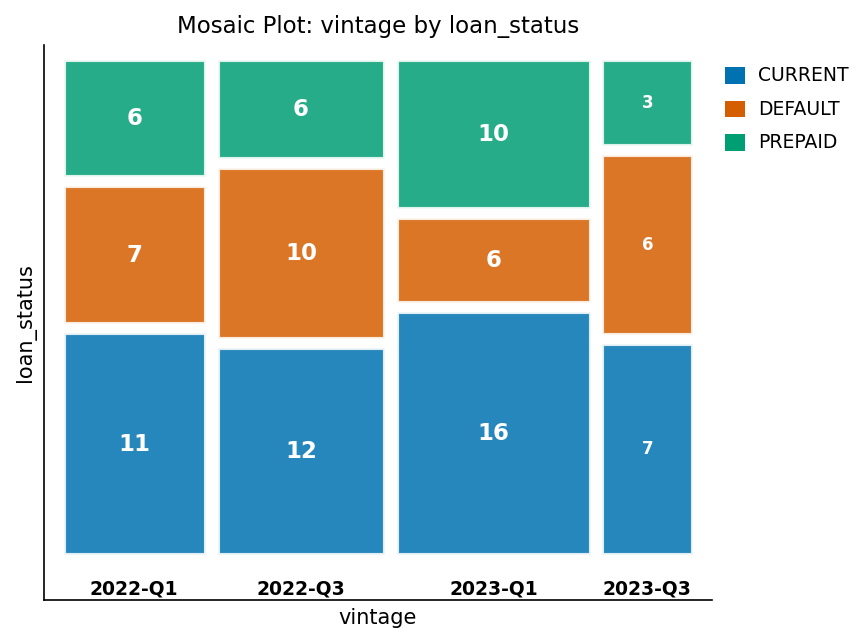

In [2]:
/* --------------------------------------------------------
   Baseline financial-ratio distributions by loan status
   -------------------------------------------------------- */
PROZEDUR MITTELWERTE DATEN=work.loan_profiles n mean std maxdec=3;
    KLASSE loan_status;
    VAR dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
AUSFÜHREN;

/* --------------------------------------------------------
   Sample composition by vintage and status
   -------------------------------------------------------- */
PROZEDUR HÄUFIGKEITEN DATEN=work.loan_profiles;
    TABLES vintage * loan_status / nocum nopercent;
AUSFÜHREN;

---

### Kanonische Diskriminanzanalyse

Passen Sie ein gepooltes kanonisches Diskriminanzmodell über alle 100 Kunden an. `OUT=` schreibt die kanonischen Scores je Kunde, `OUTSTAT=` erfasst die kanonische Struktur, die Klassenzentroide und die quadrierten Mahalanobis-Distanzen, und `DISTANCE` fordert die Distanzen zwischen den Gruppen an. Die hier angekündigte Prozedur ist genau diejenige, die ausgeführt wird: **PROC CANDISC**.

NOTE: ODS OUTPUT: CANONICALCORRELATIONS -> can_corr
NOTE: PROC CANDISC data=work.loan_profiles ncan=Some(2) prefix=Can

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: Number of Observations: 100
NOTE: Number of Classes: 3
NOTE: Class Level Information:
NOTE:   CURRENT: 46
NOTE:   DEFAULT: 29
NOTE:   PREPAID: 25
NOTE: Canonical Correlations:
NOTE:   Can1: 0.958136
NOTE:   Can2: 0.503509
NOTE: Eigenvalues of Inv(E)*H:
NOTE:                          Canonical  Approximate  Squared
NOTE:               Eigenvalue Correlation  Std Error Correlation
NOTE:   Can1       11.198645    0.958136            0.918024
NOTE:   Can2        0.339624    0.503509            0.253522
NOTE: Multivariate Statistics and F Approximations:
NOTE:   Statistic                Value     F Value  Num DF  Den DF  Pr > F
NOTE:   Wilks' Lambda         0.061194     46.65      12   184.0   0.0000
NOTE:   Pillai's Trace        1.171545     21.68      12   184.0   0.0000
NOTE:   Hotelling-Lawley   

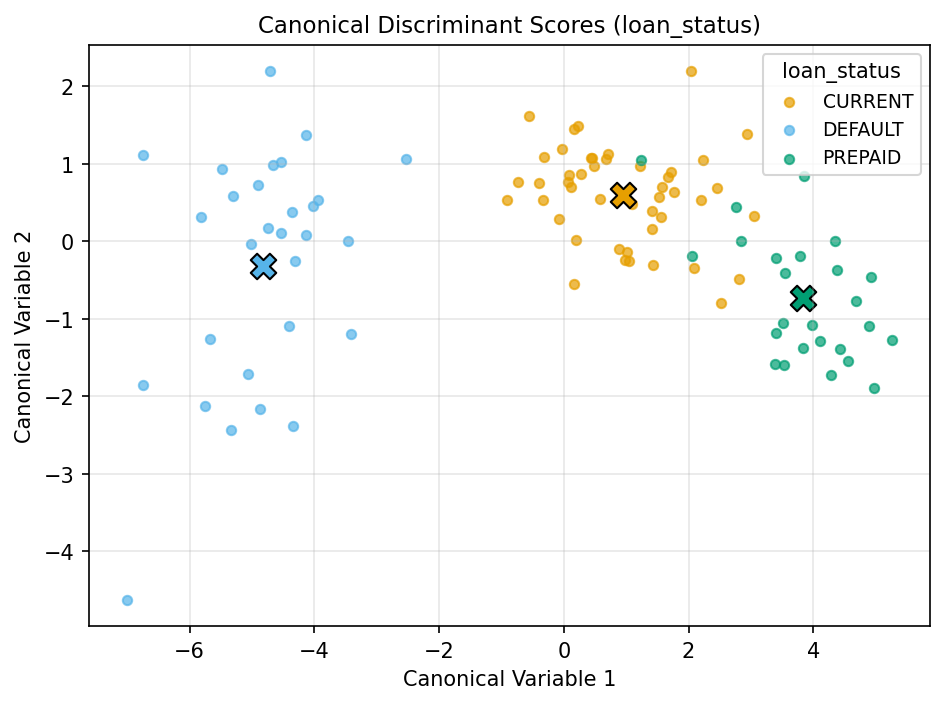

In [3]:
/* --------------------------------------------------------
   Canonical discriminant analysis of loan-status groups.
   OUT=    per-customer canonical scores (Can1, Can2)
   OUTSTAT= structure, class means, Mahalanobis distances
   -------------------------------------------------------- */
ODS AUSGABE CanonicalCorrelations=work.can_corr;

PROZEDUR CANDISC DATEN=work.loan_profiles
    out=work.risk_scores
    OUTSTAT=work.can_stat
    ncan=2
    distance;
    KLASSE loan_status;
    VAR dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
    TITEL 'Canonical Risk Discrimination of Loan-Status Groups';
AUSFÜHREN;

ODS AUSGABE CLOSE;

---

### Kanonische Korrelationen

Wie viel der Trennung zwischen den drei Gruppen jede kanonische Dimension erfasst.

In [4]:
PROZEDUR DRUCKEN DATEN=work.can_corr noobs;
    TITEL 'Canonical Correlations';
AUSFÜHREN;

                                                 Canonical Correlations                                                 

CANONICAL_VARIABLE  CANONICAL_CORRELATION  SQUARED_CANONICAL_CORRELATION     EIGENVALUE
Can1                         0.9581355246                   0.9180236835  11.1986452089
Can2                          0.503509317                   0.2535216323   0.3396235488



NOTE: PROC PRINT data=work.can_corr

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


### Kanonische Struktur (Variablenladungen)

Die Korrelation jeder ursprünglichen Finanzkennzahl mit den beiden kanonischen Dimensionen — so werden die Dimensionen interpretiert.

In [5]:
PROZEDUR DRUCKEN DATEN=work.can_stat noobs;
    WO _type_ = 'STRUCTUR';
    VAR _name_ Can1 Can2;
    TITEL 'Pooled Within-Class Canonical Structure';
AUSFÜHREN;

                                        Pooled Within-Class Canonical Structure                                         

            _NAME_       CAN1       CAN2
dti_ratio           -0.403583  -0.022755
ltv_ratio           -0.369749   0.732657
payment_to_income   -0.304192   0.117008
credit_utilization  -0.595076  -0.056264
savings_balance       0.12558   0.093182
months_delinquent   -0.323965  -0.699884



NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 3 variables


### Gruppenzentroide und Mahalanobis-Distanzen

Klassenmittelwerte auf den kanonischen Achsen (die Gruppenzentroide) und die quadrierten Mahalanobis-Distanzen zwischen jedem Gruppenpaar — die Grundlage für die Kalibrierung des Risiko-Scores.

In [6]:
PROZEDUR DRUCKEN DATEN=work.can_stat noobs;
    WO _type_ in ('CANMEAN' 'DIST');
    VAR _type_ _name_ Can1 Can2;
    TITEL 'Group Centroids (CANMEAN) and Squared Mahalanobis Distances (DIST)';
AUSFÜHREN;

                           Group Centroids (CANMEAN) and Squared Mahalanobis Distances (DIST)                           

 _TYPE_              _NAME_       CAN1       CAN2
CANMEAN  CURRENT              0.956102    0.59917
CANMEAN  DEFAULT             -4.826727  -0.316237
CANMEAN  PREPAID              3.839776  -0.735639
DIST     CURRENT to DEFAULT  34.279058          .
DIST     CURRENT to PREPAID  10.097273          .
DIST     DEFAULT to PREPAID  75.284092          .



NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

### Kanonische Diskriminanzkarte

Jeder Kunde im zweidimensionalen kanonischen Raum dargestellt, eingefärbt nach Kreditstatus. Gut getrennte Cluster zeigen an, dass die kanonischen Scores starke Gruppeninformationen tragen.

                           Group Centroids (CANMEAN) and Squared Mahalanobis Distances (DIST)                           



NOTE: PROC SGPLOT data=work.risk_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


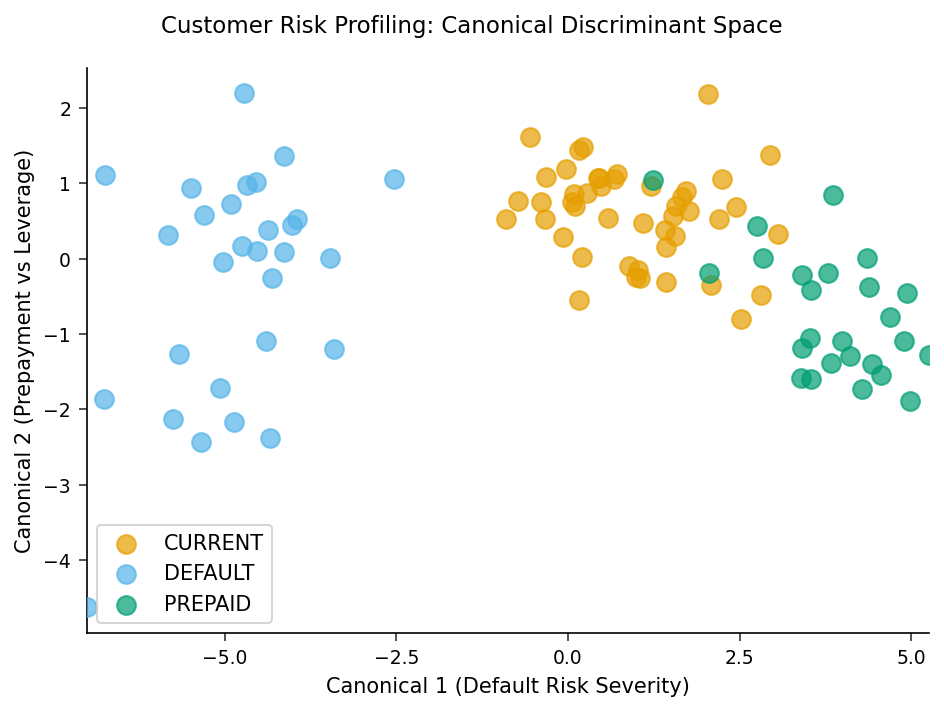

In [7]:
PROZEDUR SGPLOT DATEN=work.risk_scores;
    SCATTER x=Can1 y=Can2 / GROUP=loan_status
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.3;
    XAXIS BEZEICHNUNG='Canonical 1 (Default Risk Severity)';
    YAXIS BEZEICHNUNG='Canonical 2 (Prepayment vs Leverage)';
    TITEL 'Customer Risk Profiling: Canonical Discriminant Space';
AUSFÜHREN;

---

### Interpretation

Die beiden kanonischen Dimensionen trennen die drei Kreditstatusgruppen innerhalb dieser Stichprobe von 100 Kunden scharf (46 laufend, 29 ausgefallen, 25 vorzeitig zurückgezahlt).

**Dimension 1 — Schweregrad des Ausfallrisikos (kanonische Korrelation 0.958, 91.8% geteilte Varianz).** Diese Achse allein erklärt den überwiegenden Großteil der Gruppentrennung (Eigenwert 11.20 gegenüber 0.34 für die zweite Achse). In der gepoolten gruppeninternen kanonischen Struktur lädt sie am stärksten auf Kreditauslastung (-0.595), Schulden-Einkommens-Verhältnis (-0.404), LTV (-0.370), Monate im Verzug (-0.324) und Zahlungs-Einkommens-Verhältnis (-0.304) — jedes Maß für Verschuldung und Belastung weist in dieselbe Richtung. Da die Ladungen negativ sind, kennzeichnen niedrige (stärker negative) Can1-Scores die Kreditnehmer mit dem höchsten Risiko. Die Klassenzentroide belegen dies: ausgefallene Konten liegen bei Can1 = -4.83, laufende Konten bei +0.96 und vorzeitig zurückgezahlte Konten bei +3.84, eine saubere monotone Ordnung von schlechtester zu bester Kreditgesundheit.

**Dimension 2 — Verschuldung versus Verzug (kanonische Korrelation 0.503).** Die zweite Achse stellt das LTV-Verhältnis (+0.733) den Monaten im Verzug (-0.700) gegenüber: Sie trennt Kreditnehmer, die hoch verschuldet, aber laufend sind, von jenen mit Verzug. Sie verfeinert das Bild innerhalb von Can1, trägt aber weit weniger zur Trennung bei, wie die nahezu gleichen Can2-Zentroide für die leistenden Gruppen (laufend +0.599, vorzeitig zurückgezahlt -0.736) zeigen.

**Gruppentrennung.** Die quadrierten Mahalanobis-Distanzen zwischen den Klassenmittelwerten quantifizieren die Abstände: DEFAULT-zu-PREPAID ist mit 75.3 am größten, DEFAULT-zu-CURRENT beträgt 34.3, und CURRENT-zu-PREPAID ist mit 10.1 am kleinsten. Die beiden leistenden Gruppen liegen daher näher beieinander als jede von ihnen zur ausgefallenen Gruppe, genau wie es ein Kreditgeber erwarten würde.

**Praktische Anwendung.** Der erste kanonische Score verhält sich wie ein gebrauchsfertiger zusammengesetzter Risikoindex: Er verdichtet sechs korrelierte Kennzahlen zu einer gut getrennten Dimension, die die Kunden vom höchsten zum niedrigsten Ausfallrisiko ordnet. Portfolio-Teams können anhand von Can1-Schwellenwerten segmentieren, und die Mahalanobis-Distanzen liefern eine fundierte Grundlage, um einen neuen Antragsteller während der Scorecard-Kalibrierung der nächstgelegenen Statusgruppe zuzuordnen.

---

### Export für die Scoring-Engine

Speichern Sie die kanonischen Scores je Kunde und den Datensatz der kanonischen Statistiken (der die Zentroide und Mahalanobis-Distanzen enthält) für die nachgelagerte Scorecard-Kalibrierung.

In [8]:
/* --------------------------------------------------------
   Export canonical risk scores and canonical statistics
   -------------------------------------------------------- */
PROZEDUR EXPORT DATEN=work.risk_scores
    OUTFILE='customer_risk_canonical_scores.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;

PROZEDUR EXPORT DATEN=work.can_stat
    OUTFILE='canonical_statistics.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;

NOTE: PROC EXPORT data=work.risk_scores outfile=customer_risk_canonical_scores.csv

NOTE: Exported 100 rows to customer_risk_canonical_scores.csv.
NOTE: PROC EXPORT data=work.can_stat outfile=canonical_statistics.csv

NOTE: Exported 31 rows to canonical_statistics.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>